# Mirror Descent vs Barrier Methods
## Geometry of Constrained Optimization

We compare three methods:

- Projected Gradient Descent (PGD)
- Mirror Descent (Entropy Geometry)
- Barrier Method (Interior Point)

Goal: illustrate when **Barrier Methods outperform Mirror Descent**, particularly when the **optimum lies on the boundary**.

Experiments:

1. **1D Boundary Problem**
2. **2D Geometry Visualization**

Key insight:

> Optimization works best when **algorithm geometry matches problem geometry**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Experiment 1: Boundary Optimum

Constraint:

x ≥ 0

Objective:

f(x) = x²

True optimum:

x* = 0 (exactly on the boundary)

We compare:

- Mirror Descent (multiplicative updates)
- Barrier Method (log barrier)

In [2]:
def f(x):
    return x**2

def grad_f(x):
    return 2*x

## Mirror Descent Update

Using entropy mirror map.

Update rule:

x_{k+1} = x_k * exp(-η ∇f(x_k))

Key behavior:

As x becomes small → updates shrink → convergence slows near boundary.

In [3]:
def mirror_step_1d(x, eta):
    g = grad_f(x)
    return x * np.exp(-eta * g)

## Barrier Method

Barrier objective:

F(x) = x² − μ log(x)

Gradient:

∇F(x) = 2x − μ/x

Near boundary:

x → 0 ⇒ μ/x becomes large

This produces **strong curvature pushing the optimizer toward the boundary**.

In [4]:
def barrier_grad_1d(x, mu):
    eps = 1e-8
    return 2*x - mu/(x + eps)

def barrier_step_1d(x, mu, eta):
    g = barrier_grad_1d(x, mu)
    x_new = x - eta*g
    return max(x_new,1e-8)

In [5]:
steps = 200
eta = 0.05
mu = 0.01

x0 = 0.8

mirror_traj_1d = []
barrier_traj_1d = []

xm = x0
xb = x0

for _ in range(steps):

    xm = mirror_step_1d(xm, eta)
    xb = barrier_step_1d(xb, mu, eta)

    mirror_traj_1d.append(xm)
    barrier_traj_1d.append(xb)

mirror_traj_1d = np.array(mirror_traj_1d)
barrier_traj_1d = np.array(barrier_traj_1d)

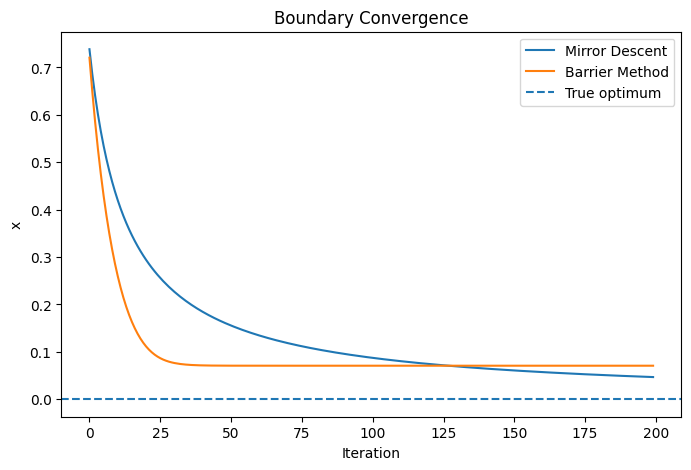

In [6]:
plt.figure(figsize=(8,5))

plt.plot(mirror_traj_1d,label="Mirror Descent")
plt.plot(barrier_traj_1d,label="Barrier Method")

plt.axhline(0,linestyle="--",label="True optimum")

plt.xlabel("Iteration")
plt.ylabel("x")
plt.title("Boundary Convergence")

plt.legend()
plt.show()

## Observation

Mirror Descent slows down near the boundary.

Reason:
Multiplicative updates shrink as variables approach zero.

Barrier Method converges faster because:

- Log barrier increases curvature near boundary
- Gradient magnitude increases as x → 0

Thus barrier methods are effective when **optimal solutions lie on constraint boundaries**.

# Experiment 2: Geometry Visualization (2D)

We now visualize optimization trajectories.

Constraint:

x ≥ 0 , y ≥ 0

Objective:

f(x,y) = (x−1)² + (y−0.1)²

The optimum lies **near the boundary**.

We compare:

- PGD
- Mirror Descent
- Barrier Method

This shows how **each algorithm follows a different geometry**.

In [7]:
def f2(x):
    return (x[0]-1)**2 + (x[1]-0.1)**2

def grad_f2(x):
    return np.array([
        2*(x[0]-1),
        2*(x[1]-0.1)
    ])

In [8]:
def pgd_step(x,eta):

    g = grad_f2(x)
    x = x - eta*g
    x = np.maximum(x,0)

    return x

In [9]:
def mirror_step_2d(x,eta):

    g = grad_f2(x)
    x = x * np.exp(-eta*g)
    return x

In [10]:
def barrier_grad_2d(x,mu):

    eps = 1e-8
    g = grad_f2(x)
    barrier = np.array([
        -mu/(x[0] + eps),
        -mu/(x[1] + eps)
    ])

    return g + barrier


def barrier_step_2d(x,mu,eta):

    g = barrier_grad_2d(x,mu)
    x = x - eta*g
    x = np.maximum(x,1e-6)

    return x

In [11]:
steps = 120
eta = 0.1
mu = 0.01

x0 = np.array([0.6,0.8])

pgd_traj_2d = []
mirror_traj_2d = []
barrier_traj_2d = []

xp = x0.copy()
xm = x0.copy()
xb = x0.copy()

for _ in range(steps):

    xp = pgd_step(xp,eta)
    xm = mirror_step_2d(xm,eta)
    xb = barrier_step_2d(xb,mu,eta)

    pgd_traj_2d.append(xp.copy())
    mirror_traj_2d.append(xm.copy())
    barrier_traj_2d.append(xb.copy())

pgd_traj_2d = np.array(pgd_traj_2d)
mirror_traj_2d = np.array(mirror_traj_2d)
barrier_traj_2d = np.array(barrier_traj_2d)

In [12]:
x = np.linspace(0,1.5,200)
y = np.linspace(0,1.2,200)

X,Y = np.meshgrid(x,y)

Z = (X-1)**2 + (Y-0.1)**2

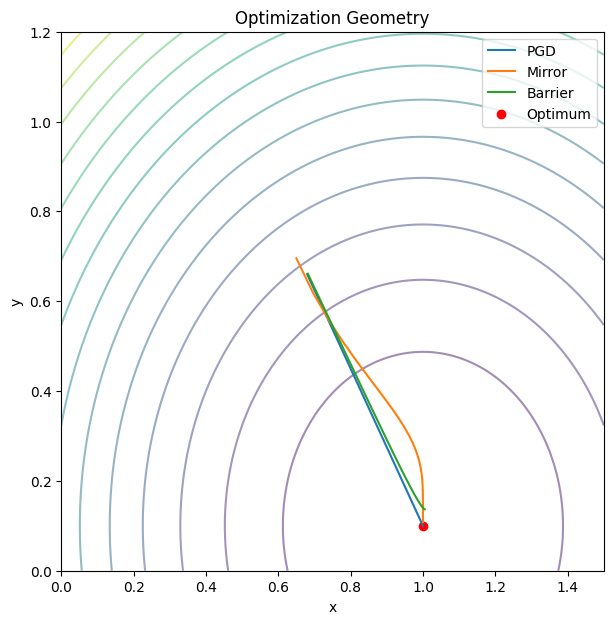

In [ ]:
plt.figure(figsize=(7,7))

plt.contour(X,Y,Z,20,alpha=0.5)

plt.plot(pgd_traj_2d[:,0],pgd_traj_2d[:,1],label="PGD")
plt.plot(mirror_traj_2d[:,0],mirror_traj_2d[:,1],label="Mirror")
plt.plot(barrier_traj_2d[:,0],barrier_traj_2d[:,1],label="Barrier")

plt.scatter([1],[0.1],c="red",label="Optimum")
plt.xlim(0,1.5)
plt.ylim(0,1.2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimization Geometry")

plt.legend()

plt.show()

In [14]:
obj_pgd = [f2(x) for x in pgd_traj_2d]
obj_mirror = [f2(x) for x in mirror_traj_2d]
obj_barrier = [f2(x) for x in barrier_traj_2d]

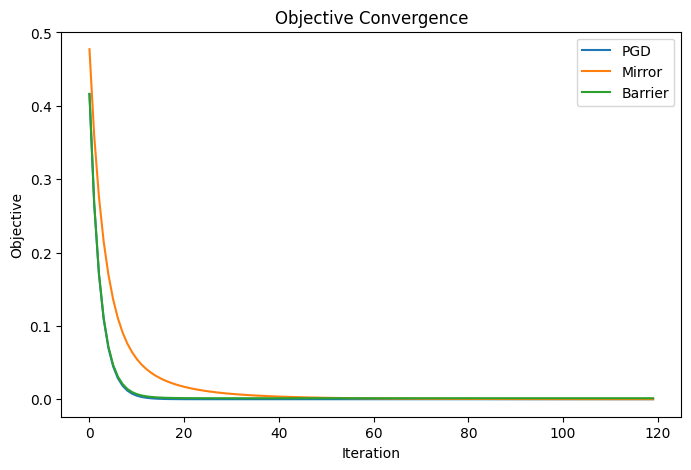

In [15]:
plt.figure(figsize=(8,5))

plt.plot(obj_pgd,label="PGD")
plt.plot(obj_mirror,label="Mirror")
plt.plot(obj_barrier,label="Barrier")

plt.xlabel("Iteration")
plt.ylabel("Objective")

plt.title("Objective Convergence")

plt.legend()
plt.show()

# Geometry Insight

Different algorithms assume different geometries:

| Method | Geometry | Strength |
|------|------|------|
PGD | Euclidean | simple constraints |
Mirror Descent | KL / entropy | probability/simplex problems |
Barrier Methods | interior-point | boundary optima |

Observation from visualization:

- PGD zig-zags due to projection
- Mirror follows curved KL trajectory
- Barrier follows an interior path toward the boundary optimum

Key lesson:

> Optimization performance depends on **matching algorithm geometry with problem geometry**.